# 223 — The peptide-binding groove and the Ig domain, in the same molecule

**Question:** every MHC class I and class II gene is a fast-evolving peptide-binding
platform bolted to a conserved immunoglobulin C1-set domain (notebook
[220](./220_mhc_region_map_and_coverage.ipynb) §2). They are searched in one query, scored by
one arm, against one target. Does a homology search recover them equally?

This is the cleanest controlled contrast the MHC offers. The platform holds the residues that
touch the peptide and is the most polymorphic coding sequence in the human genome. The C1-set
Ig domain is a fold shared with antibodies, T-cell receptors and hundreds of other IgSF
proteins. Everything else — the query, the target database, the tool, the divergence — is
held fixed between them.

The answer turns out to be a lesson about the *metric* rather than about detection, and it
is the thing to be most careful about when quoting any number off this run.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import polars as pl

import mhc_region_utils as mu
import ortholog_analysis_utils as ou

FIG_DIR = Path("../figures")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight", "font.size": 10})

gene_map = mu.load_chr6_gene_map()
core = gene_map.filter(pl.col("mhc_class").is_not_null())
truth = mu.load_human_truth()
dl = mu.load_domain_level().with_columns(arm=pl.col("tool") + "." + pl.col("variant"))

# The 51 true (gene, family) pairs on the 24 curated MHC genes.
TRUE = (truth.rename({"accession": "query_acc"})
             .join(core.select(query_acc="accession", hgnc_symbol="hgnc_symbol",
                               mhc_class="mhc_class"), on="query_acc", how="inner")
             .with_columns(role=mu.domain_role(pl.col("pfam_id"))))

ARMS = ["hmmer3_phmmer.default", "hmmer3_jackhmmer.n3", "hhblits.single_seq",
        "mmseqs2_seqseq.s7", "mmseqs2_iterative.s7", "foldseek.3di_aa",
        "reseek.verysensitive", "prostt5.3di_from_seq", "folddisco.motif",
        "kmerseek.hp_pbotc_1st_ed2_k19_lcTrue"]
ARM_SHORT = {a: a.split(".")[0] for a in ARMS}
ARM_SHORT["kmerseek.hp_pbotc_1st_ed2_k19_lcTrue"] = "kmerseek k19"


def recovery(species):
    # Full grid of (true domain x arm). A pair an arm never called on has no row in the
    # domain table and must be filled as "not found", not dropped -- dropping it silently
    # shrinks the denominator to only the domains the arm already found.
    grid = TRUE.join(pl.DataFrame({"arm": ARMS}), how="cross")
    got = (dl.filter(pl.col("species") == species)
             .select("query_acc", "pfam_id", "arm", "found", "best_iou", "best_cover"))
    return (grid.join(got, on=["query_acc", "pfam_id", "arm"], how="left")
                .with_columns(found=pl.col("found").fill_null(False),
                              best_iou=pl.col("best_iou").fill_null(0.0),
                              best_cover=pl.col("best_cover").fill_null(0.0)))


mouse = recovery("mouse")
print(f"true MHC domain instances: {TRUE.height}")
print(TRUE.group_by("role").len().sort("len", descending=True))

true MHC domain instances: 51
shape: (4, 2)
┌──────────────────────────┬─────┐
│ role                     ┆ len │
│ ---                      ┆ --- │
│ str                      ┆ u32 │
╞══════════════════════════╪═════╡
│ Ig C1-set                ┆ 22  │
│ peptide-binding platform ┆ 21  │
│ class I tail             ┆ 4   │
│ ABC transporter          ┆ 4   │
└──────────────────────────┴─────┘


## 1. The Ig domain is recovered by everything; the class II platform by nothing

Recovery here is the run's own definition — a call whose transferred Pfam family matches and
whose interval reaches IoU ≥ 0.5 against the true domain. Target is mouse, 100 Mya, the
easiest comparison in the run.

The class I platform (PF00129) and the class II platforms (PF00993, PF00969) are separated
because they do not behave the same way, and the reason is in §2.

mouse — domains recovered / domains present, per Pfam family (IoU ≥ 0.5):
shape: (10, 8)
┌──────────────────────────────────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┐
│ arm                                  ┆ PF00129 ┆ PF00993 ┆ PF00969 ┆ PF07654 ┆ PF06623 ┆ PF00664 ┆ PF00005 │
│ ---                                  ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---     │
│ str                                  ┆ str     ┆ str     ┆ str     ┆ str     ┆ str     ┆ str     ┆ str     │
╞══════════════════════════════════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╡
│ reseek.verysensitive                 ┆ 8/8     ┆ 0/6     ┆ 0/7     ┆ 22/22   ┆ 0/4     ┆ 0/2     ┆ 2/2     │
│ hmmer3_jackhmmer.n3                  ┆ 8/8     ┆ 0/6     ┆ 0/7     ┆ 22/22   ┆ 0/4     ┆ 2/2     ┆ 2/2     │
│ folddisco.motif                      ┆ 8/8     ┆ 6/6     ┆ 7/7     ┆ 22/22   ┆ 4/4     ┆ 2/2     ┆ 2/2     │
│ hhblits.single_seq   

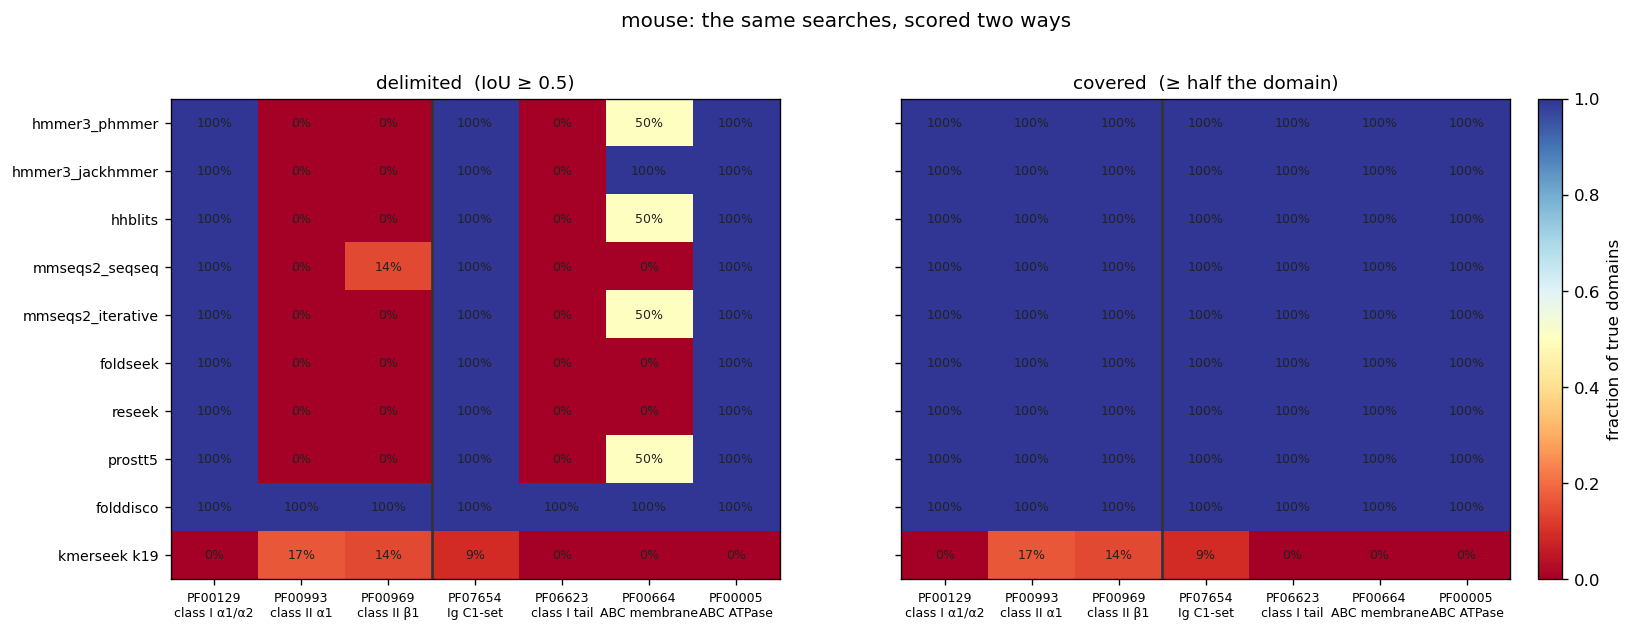

In [2]:
def by_family(frame, value):
    t = (frame.group_by("arm", "pfam_id")
              .agg(pl.col(value).sum().alias("n") if value == "found"
                   else pl.col(value).mean().alias("n"),
                   pl.len().alias("total")))
    return t


fam_order = ["PF00129", "PF00993", "PF00969", "PF07654", "PF06623", "PF00664", "PF00005"]
FAM_LABEL = {"PF00129": "PF00129\nclass I α1/α2", "PF00993": "PF00993\nclass II α1",
             "PF00969": "PF00969\nclass II β1", "PF07654": "PF07654\nIg C1-set",
             "PF06623": "PF06623\nclass I tail", "PF00664": "PF00664\nABC membrane",
             "PF00005": "PF00005\nABC ATPase"}

rec = by_family(mouse, "found")
wide = (rec.with_columns(cell=pl.col("n").cast(pl.String) + "/" + pl.col("total").cast(pl.String))
           .pivot(on="pfam_id", index="arm", values="cell"))
wide = wide.select(["arm"] + [f for f in fam_order if f in wide.columns])
print("mouse — domains recovered / domains present, per Pfam family (IoU ≥ 0.5):")
with pl.Config(tbl_rows=20, tbl_width_chars=190, fmt_str_lengths=45):
    print(wide)

# same table, but asking only whether the call COVERED the domain at all
cov = (mouse.with_columns(covered=pl.col("best_cover") >= 0.5)
            .group_by("arm", "pfam_id")
            .agg(pl.col("covered").sum().alias("n"), pl.len().alias("total")))
wide_c = (cov.with_columns(cell=pl.col("n").cast(pl.String) + "/" + pl.col("total").cast(pl.String))
             .pivot(on="pfam_id", index="arm", values="cell"))
wide_c = wide_c.select(["arm"] + [f for f in fam_order if f in wide_c.columns])
print("\nmouse — domains COVERED (call overlaps ≥ half the domain), same searches:")
with pl.Config(tbl_rows=20, tbl_width_chars=190, fmt_str_lengths=45):
    print(wide_c)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), sharey=True)
for ax, tbl, title in [(axes[0], rec, "delimited  (IoU ≥ 0.5)"),
                       (axes[1], cov, "covered  (≥ half the domain)")]:
    mat = np.full((len(ARMS), len(fam_order)), np.nan)
    for i, a in enumerate(ARMS):
        for j, f in enumerate(fam_order):
            r = tbl.filter((pl.col("arm") == a) & (pl.col("pfam_id") == f))
            if r.height:
                mat[i, j] = r["n"][0] / r["total"][0]
    im = ax.imshow(mat, cmap="RdYlBu", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(fam_order)))
    ax.set_xticklabels([FAM_LABEL[f] for f in fam_order], fontsize=7.5)
    ax.set_title(title, fontsize=11)
    for i in range(len(ARMS)):
        for j in range(len(fam_order)):
            if not np.isnan(mat[i, j]):
                ax.text(j, i, f"{mat[i, j]:.0%}", ha="center", va="center", fontsize=7.5,
                        color="#222222")
    ax.axvline(2.5, color="#333333", lw=1.6)
axes[0].set_yticks(range(len(ARMS)))
axes[0].set_yticklabels([ARM_SHORT[a] for a in ARMS], fontsize=8.5)
fig.suptitle("mouse: the same searches, scored two ways", y=1.02)
fig.colorbar(im, ax=axes, label="fraction of true domains", fraction=0.02, pad=0.02)
fig.savefig(FIG_DIR / "223_platform_vs_ig_recovery.png", dpi=200, bbox_inches="tight")

## 2. It is not sensitivity — the region is found and the boundary is not

The two panels above disagree completely for the class II platforms: 0% delimited, 100%
covered. Those calls do land on the domain; they are simply much longer than it.

Plotting IoU against cover for every true domain makes the failure mode explicit. A domain
missed for lack of sensitivity sits at the origin. A domain found but not delimited sits at
the top-left: cover 1.0, IoU below the 0.5 line.

domains fully covered but scored as misses: 18 of 51
shape: (18, 6)
┌─────────────┬───────────────────┬─────────┬──────────────────────────┬──────────┬────────────┐
│ hgnc_symbol ┆ mhc_class         ┆ pfam_id ┆ role                     ┆ best_iou ┆ best_cover │
│ ---         ┆ ---               ┆ ---     ┆ ---                      ┆ ---      ┆ ---        │
│ str         ┆ str               ┆ str     ┆ str                      ┆ f64      ┆ f64        │
╞═════════════╪═══════════════════╪═════════╪══════════════════════════╪══════════╪════════════╡
│ TAP1        ┆ processing (ctrl) ┆ PF00664 ┆ ABC transporter          ┆ 0.459    ┆ 1.0        │
│ HLA-A       ┆ I classical       ┆ PF06623 ┆ class I tail             ┆ 0.156    ┆ 1.0        │
│ HLA-B       ┆ I classical       ┆ PF06623 ┆ class I tail             ┆ 0.099    ┆ 0.92       │
│ HLA-C       ┆ I classical       ┆ PF06623 ┆ class I tail             ┆ 0.155    ┆ 1.0        │
│ HLA-E       ┆ I non-classical   ┆ PF06623 ┆ class I tail 

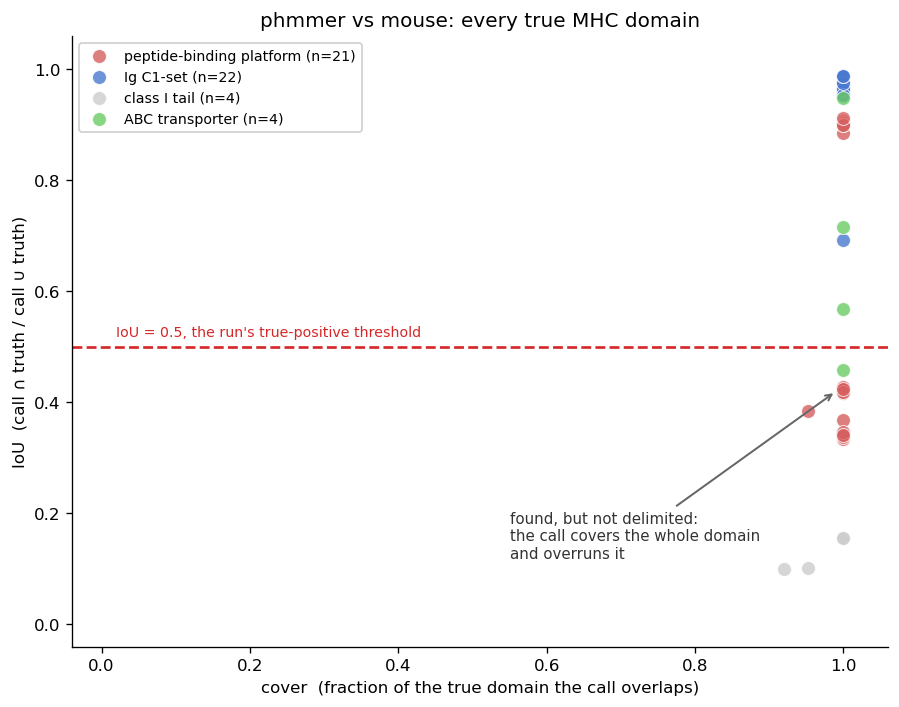

In [3]:
sub = mouse.filter(pl.col("arm") == "hmmer3_phmmer.default")
fig, ax = plt.subplots(figsize=(7.6, 6.0))
for role, colour in mu.DOMAIN_ROLE_COLORS.items():
    s = sub.filter(pl.col("role") == role)
    if s.height == 0:
        continue
    ax.scatter(s["best_cover"], s["best_iou"], s=70, color=colour, alpha=0.8,
               edgecolor="white", linewidth=0.6, label=f"{role} (n={s.height})")
ax.axhline(0.5, color="#D62728", lw=1.6, ls="--")
ax.text(0.02, 0.52, "IoU = 0.5, the run's true-positive threshold", color="#D62728", fontsize=8.5)
ax.annotate("found, but not delimited:\nthe call covers the whole domain\nand overruns it",
            (0.99, 0.42), (0.55, 0.12), fontsize=9, color="#333333",
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#666666"))
ax.set_xlabel("cover  (fraction of the true domain the call overlaps)")
ax.set_ylabel("IoU  (call ∩ truth / call ∪ truth)")
ax.set_title("phmmer vs mouse: every true MHC domain")
ax.set_xlim(-0.04, 1.06)
ax.set_ylim(-0.04, 1.06)
ax.legend(fontsize=8.5, loc="upper left", framealpha=0.95)
for s_ in ("right", "top"):
    ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "223_iou_vs_cover.png", dpi=200)

miss = sub.filter((pl.col("best_cover") >= 0.9) & (pl.col("best_iou") < 0.5))
print(f"domains fully covered but scored as misses: {miss.height} of {sub.height}")
with pl.Config(tbl_rows=20, tbl_width_chars=160):
    print(miss.select("hgnc_symbol", "mhc_class", "pfam_id", "role",
                      pl.col("best_iou").round(3), pl.col("best_cover").round(3))
              .sort("role", "hgnc_symbol"))

## 3. Why: a domain can only be delimited if the database contains it on its own

The boundary a search reports is inherited from the target it matched. The pipeline
transfers every Pfam family annotated on a target protein onto the aligned interval, so a
full-length alignment to a mouse class II β chain transfers **both** PF00969 and PF07654
onto the same full-length interval. Against a 105-residue β1 domain inside a 266-residue
protein, that is IoU ≈ 0.4 — a miss — no matter how good the alignment is.

The Ig C1-set escapes this because the target proteome contains many proteins where a C1-set
appears **without** an MHC platform next to it. Those give short, tight alignments and a
correct boundary. The class II platforms have no such partner-free examples anywhere.

The table below is the mechanism, counted from the run's own target domain maps.

Target proteins carrying each family, and how many carry it as their ONLY family:
shape: (21, 5)
┌───────────┬─────────┬────────────┬─────────────────────┬────────────┐
│ species   ┆ pfam_id ┆ n_proteins ┆ n_carrying_it_alone ┆ frac_alone │
│ ---       ┆ ---     ┆ ---        ┆ ---                 ┆ ---        │
│ str       ┆ str     ┆ i64        ┆ i64                 ┆ f64        │
╞═══════════╪═════════╪════════════╪═════════════════════╪════════════╡
│ chicken   ┆ PF00005 ┆ 9          ┆ 0                   ┆ 0.0        │
│ chicken   ┆ PF00129 ┆ 2          ┆ 0                   ┆ 0.0        │
│ chicken   ┆ PF00664 ┆ 4          ┆ 0                   ┆ 0.0        │
│ chicken   ┆ PF00969 ┆ 3          ┆ 0                   ┆ 0.0        │
│ chicken   ┆ PF00993 ┆ 1          ┆ 0                   ┆ 0.0        │
│ chicken   ┆ PF06623 ┆ 0          ┆ 0                   ┆ null       │
│ chicken   ┆ PF07654 ┆ 11         ┆ 2                   ┆ 0.182      │
│ mouse     ┆ PF00005 ┆ 53         ┆ 1 

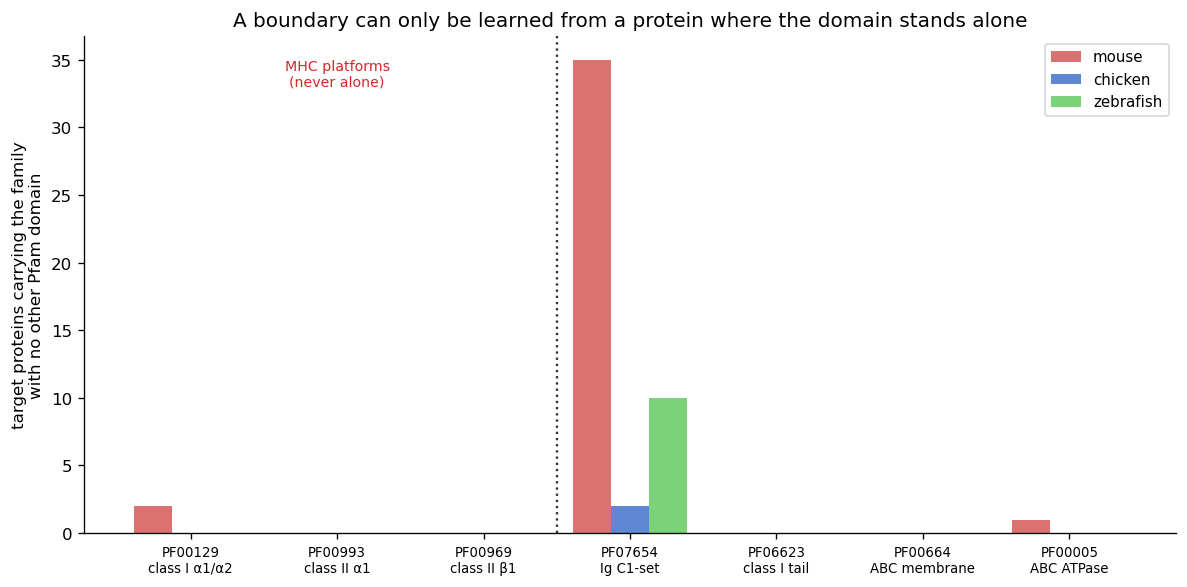

In [4]:
rows = []
for sp in ["mouse", "chicken", "zebrafish"]:
    dm = mu.load_target_domain_map(sp)
    for fam in fam_order:
        prots = dm.filter(pl.col("pfam_id") == fam)["accession"].unique().to_list()
        if len(prots) == 0:
            rows.append({"species": sp, "pfam_id": fam, "n_proteins": 0,
                         "n_carrying_it_alone": 0, "frac_alone": None})
            continue
        s = dm.filter(pl.col("accession").is_in(prots))
        alone = (s.group_by("accession").agg(pl.col("pfam_id").n_unique().alias("nf"))
                  .filter(pl.col("nf") == 1).height)
        rows.append({"species": sp, "pfam_id": fam, "n_proteins": len(prots),
                     "n_carrying_it_alone": alone,
                     "frac_alone": round(alone / len(prots), 3)})
occ = pl.DataFrame(rows)
print("Target proteins carrying each family, and how many carry it as their ONLY family:")
with pl.Config(tbl_rows=40, tbl_width_chars=170):
    print(occ.sort("species", "pfam_id"))

fig, ax = plt.subplots(figsize=(10, 5.0))
x = np.arange(len(fam_order))
w = 0.26
for i, sp in enumerate(["mouse", "chicken", "zebrafish"]):
    vals = [occ.filter((pl.col("species") == sp) & (pl.col("pfam_id") == f))["n_carrying_it_alone"].sum()
            for f in fam_order]
    ax.bar(x + (i - 1) * w, vals, w, label=sp,
           color=["#D65F5F", "#4878CF", "#6ACC65"][i], alpha=0.88)
ax.set_xticks(x)
ax.set_xticklabels([FAM_LABEL[f] for f in fam_order], fontsize=8)
ax.set_ylabel("target proteins carrying the family\nwith no other Pfam domain")
ax.set_title("A boundary can only be learned from a protein where the domain stands alone")
ax.axvline(2.5, color="#333333", lw=1.4, ls=":")
ax.text(1.0, ax.get_ylim()[1] * 0.9, "MHC platforms\n(never alone)", ha="center", fontsize=8.5,
        color="#D62728")
ax.legend(fontsize=9)
for s_ in ("right", "top"):
    ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "223_domain_cooccurrence.png", dpi=200)

## 4. The class I platform is the exception that shows the rule

Class I comes out at 100% delimited where class II comes out at 0%, and the difference is
not biological — it is how Pfam happens to carve the two molecules up.

Pfam models the class I platform as **one** family covering α1 *and* α2 together (PF00129,
~179 residues of a 365-residue protein — 49% of it). It models the class II platform as
**half** a platform, α1 alone (PF00993, ~80 aa, 31%) or β1 alone (PF00969, ~105 aa, 40%),
because in class II the two halves sit on different chains.

That fraction is the ceiling on IoU for a full-length call, and it is why the two behave
differently. PF00129 starts near the threshold and only needs a slightly tighter-than-
full-length call to clear it — and mouse supplies two proteins carrying PF00129 with no
partner, which is where such calls come from. The class II halves start well below the
threshold and mouse supplies no partner-free example of either, so no call can reach it.

Same fold, same function, same searches, opposite scores, and the difference is a modelling
convention in the truth set meeting a fixed IoU cut.

In [5]:
lens = (TRUE.with_columns(domain_len=pl.col("domain_end") - pl.col("domain_start") + 1)
            .group_by("pfam_id", "role")
            .agg(pl.col("domain_len").mean().round(0).alias("mean_domain_len"),
                 pl.col("protein_length").mean().round(0).alias("mean_protein_len"),
                 pl.len().alias("n"))
            .with_columns(frac_of_protein=(pl.col("mean_domain_len") / pl.col("mean_protein_len")).round(3)))
print("Domain length as a fraction of its protein — the ceiling on IoU for a full-length call:")
with pl.Config(tbl_rows=20, tbl_width_chars=170):
    print(lens.sort("frac_of_protein", descending=True))
print("\nA full-length alignment scores IoU = frac_of_protein. The 0.5 threshold is")
print("reachable only for families above 0.5 in that column.")

# Does this hold across every species where the platforms exist?
rows = []
for sp in ["mouse", "chicken", "zebrafish"]:
    r = recovery(sp)
    for label, expr in [("class I platform", pl.col("pfam_id") == "PF00129"),
                        ("class II platform", pl.col("pfam_id").is_in(["PF00993", "PF00969"])),
                        ("Ig C1-set", pl.col("pfam_id") == "PF07654")]:
        s = r.filter(expr & (pl.col("arm") != "kmerseek.hp_pbotc_1st_ed2_k19_lcTrue"))
        rows.append({"species": sp, "group": label,
                     "delimited": round(s["found"].mean(), 3),
                     "covered": round((s["best_cover"] >= 0.5).mean(), 3)})
print()
print("Across the three species that have MHC molecules (9 baseline arms pooled):")
with pl.Config(tbl_rows=20, tbl_width_chars=160):
    print(pl.DataFrame(rows))

Domain length as a fraction of its protein — the ceiling on IoU for a full-length call:
shape: (7, 6)
┌─────────┬──────────────────────────┬─────────────────┬──────────────────┬─────┬─────────────────┐
│ pfam_id ┆ role                     ┆ mean_domain_len ┆ mean_protein_len ┆ n   ┆ frac_of_protein │
│ ---     ┆ ---                      ┆ ---             ┆ ---              ┆ --- ┆ ---             │
│ str     ┆ str                      ┆ f64             ┆ f64              ┆ u32 ┆ f64             │
╞═════════╪══════════════════════════╪═════════════════╪══════════════════╪═════╪═════════════════╡
│ PF00129 ┆ peptide-binding platform ┆ 179.0           ┆ 363.0            ┆ 8   ┆ 0.493           │
│ PF00969 ┆ peptide-binding platform ┆ 105.0           ┆ 265.0            ┆ 7   ┆ 0.396           │
│ PF00664 ┆ ABC transporter          ┆ 272.0           ┆ 747.0            ┆ 2   ┆ 0.364           │
│ PF00993 ┆ peptide-binding platform ┆ 80.0            ┆ 256.0            ┆ 6   ┆ 0.312           

## Summary

In [6]:
p = mouse.filter(pl.col("arm") == "hmmer3_phmmer.default")
for label, expr in [("class I platform (PF00129)", pl.col("pfam_id") == "PF00129"),
                    ("class II platform (PF00993/PF00969)",
                     pl.col("pfam_id").is_in(["PF00993", "PF00969"])),
                    ("Ig C1-set (PF07654)", pl.col("pfam_id") == "PF07654")]:
    s = p.filter(expr)
    print(f"{label:38s} delimited {s['found'].sum()}/{s.height}   "
          f"covered {(s['best_cover'] >= 0.5).sum()}/{s.height}   "
          f"mean IoU {s['best_iou'].mean():.2f}")

class I platform (PF00129)             delimited 8/8   covered 8/8   mean IoU 0.90
class II platform (PF00993/PF00969)    delimited 0/13   covered 13/13   mean IoU 0.38
Ig C1-set (PF07654)                    delimited 22/22   covered 22/22   mean IoU 0.96


The within-molecule contrast does not say what it looks like it says, and that is the
result.

**Read off the run's default metric, the class II peptide-binding groove is invisible.** Every
one of the nine baseline tools recovers 0 of the 13 class II platform domains in mouse, at
100 Mya, while recovering 22 of 22 Ig C1-set domains in the same proteins on the same
searches.

**It is not a detection failure.** Those same calls cover the class II platform completely —
cover 1.0, IoU ≈ 0.4. The groove is found every time. What fails is the boundary, and it
fails because a full-length alignment cannot delimit a domain that occupies 40% of its
protein when the threshold is IoU 0.5.

**The cause is in the target database, not the tool.** A search inherits its boundary from
whatever it matched. The Ig C1-set can be delimited because 35 mouse proteins carry a C1-set
with no other Pfam domain beside it. The class II platforms are carried by 5 and 9 mouse
proteins respectively and **none** of them carries one alone — every instance sits next to a
C1-set. There is nothing in the database from which a tight class II boundary could be
learned.

**So the class I / class II gap is a Pfam modelling convention.** PF00129 covers α1+α2 as one
family and clears the threshold; PF00993 and PF00969 each cover half a platform and cannot.
Same fold, same function, opposite scores.

**What this means for anything quoted off this run.** Domain-level recall at IoU ≥ 0.5 is a
boundary metric, not a homology metric, and for short domains inside multi-domain proteins
the two come apart completely. Every MHC recall number in notebooks 221 and 222 carries this,
and so does the kmerseek-versus-baseline gap in 221 §1 — which is the same failure mode, one
step further along.